In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001474-100507/00001474-100507_ap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001474-100507/00001474-100507_nap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001263-100507/00001263-100507_nap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001263-100507/00001263-100507_ap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001355-100507/00001355-100507_nap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001355-100507/00001355-100507_ap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001208-100507/00001208-100507_ap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001208-100507/00001208-100507_nap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-

In [2]:
import subprocess
subprocess.run(['pip','install','librosa','--quiet'], capture_output=True)
print('librosa ready')


librosa ready


In [3]:
import os, gc, random, warnings, time, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import librosa, psutil
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve)

warnings.filterwarnings('ignore')

def mem_info():
    ram = psutil.virtual_memory()
    msg = f'RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB ({ram.percent:.0f}%)'
    if torch.cuda.is_available():
        msg += f'  |  GPU: {torch.cuda.memory_allocated(0)/1e9:.1f}/{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB'
    print(msg)

def disk_info(p='/kaggle/working'):
    t,u,f = shutil.disk_usage(p); print(f'Disk: {u/1e9:.1f}/{t/1e9:.1f} GB | {f/1e9:.1f} GB free')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
mem_info(); disk_info()
print('Imports OK')


Device : cuda
GPU    : Tesla T4
RAM: 1.2/33.7 GB (5%)  |  GPU: 0.0/15.6 GB
Disk: 0.0/21.0 GB | 20.9 GB free
Imports OK


In [4]:
# ══════════════════════════════════════════════════════
# CONFIGURATION  (unchanged from your working version)
# ══════════════════════════════════════════════════════

AUDIO_DIR   = Path('/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF')
CACHE_DIR   = Path('/kaggle/working/mel_cache')
RESULTS_DIR = Path('/kaggle/working/results')
CKPT_DIR    = Path('/kaggle/working/ckpts')
for d in [CACHE_DIR, RESULTS_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE  = 16000
CLIP_SEC     = 10.0
CLIP_SAMPLES = int(CLIP_SEC * SAMPLE_RATE)   # 160,000

N_MELS      = 64
HOP_LENGTH  = 512
N_FFT       = 1024
FMIN        = 50.0
FMAX        = 8000.0
TIME_STEPS  = 128
N_FEATURES  = N_MELS * 3    # 192

MAX_PATIENTS = None
N_FOLDS      = 5
MAX_EPOCHS   = 60
EARLY_STOP   = 12
BATCH_SIZE   = 64
LR           = 1e-4
WEIGHT_DECAY = 1e-4
SEED         = 42
BILSTM_HIDDEN = 64
BILSTM_LAYERS = 2
DROPOUT       = 0.3

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed()

print(f'Config OK | {TIME_STEPS}×{N_FEATURES} features | batch={BATCH_SIZE} | lr={LR}')


Config OK | 128×192 features | batch=64 | lr=0.0001


In [5]:
# ══════════════════════════════════════════════════════
# FIND .NPY FILES  (unchanged — working correctly)
# ══════════════════════════════════════════════════════

def find_npy_files(audio_dir, max_patients=None):
    audio_dir = Path(audio_dir)
    records, pids = [], set()
    for patient_dir in sorted(audio_dir.iterdir()):
        if not patient_dir.is_dir(): continue
        pid = patient_dir.name
        for fpath, label in [(patient_dir/f'{pid}_ap.npy', 1),
                              (patient_dir/f'{pid}_nap.npy', 0)]:
            if fpath.exists():
                arr = np.load(fpath, mmap_mode='r')
                records.append((str(fpath), label, pid, arr.shape[0]))
                pids.add(pid); del arr
    pids = sorted(pids)
    if max_patients and len(pids) > max_patients:
        pids = pids[:max_patients]; keep = set(pids)
        records = [r for r in records if r[2] in keep]
    tap = sum(n for _,l,_,n in records if l==1)
    tna = sum(n for _,l,_,n in records if l==0)
    tot = tap + tna
    print(f'Patients:{len(pids)}  AP={tap:,}({tap/tot*100:.1f}%)  NAP={tna:,}({tna/tot*100:.1f}%)  Total={tot:,}')
    if records:
        a = np.load(records[0][0], mmap_mode='r')
        print(f'Shape: {a.shape}  dtype={a.dtype}'); del a
    return records, np.array(pids)

npy_records, npy_pids = find_npy_files(AUDIO_DIR, MAX_PATIENTS)
print('Files found OK'); mem_info()


Patients:192  AP=64,585(62.6%)  NAP=38,625(37.4%)  Total=103,210
Shape: (212, 160000)  dtype=float16
Files found OK
RAM: 1.2/33.7 GB (5%)  |  GPU: 0.0/15.6 GB


In [6]:
# ══════════════════════════════════════════════════════
# FEATURE EXTRACTION  (unchanged — working correctly)
# ══════════════════════════════════════════════════════

def extract_mel_features(waveform):
    waveform = waveform.astype(np.float32)
    if len(waveform) < CLIP_SAMPLES:
        waveform = np.pad(waveform, (0, CLIP_SAMPLES - len(waveform)))
    else:
        waveform = waveform[:CLIP_SAMPLES]
    mel    = librosa.feature.melspectrogram(y=waveform, sr=SAMPLE_RATE, n_mels=N_MELS,
               hop_length=HOP_LENGTH, n_fft=N_FFT, fmin=FMIN, fmax=FMAX, power=2.0)
    lm     = librosa.power_to_db(mel, ref=np.max)
    d1     = librosa.feature.delta(lm, order=1, width=5)
    d2     = librosa.feature.delta(lm, order=2, width=5)
    feat   = np.concatenate([lm, d1, d2], axis=0).T   # (T_raw, 192)
    if feat.shape[0] >= TIME_STEPS:
        feat = feat[:TIME_STEPS, :]
    else:
        feat = np.pad(feat, ((0, TIME_STEPS - feat.shape[0]), (0, 0)))
    mean = feat.mean(axis=0, keepdims=True)
    std  = feat.std(axis=0, keepdims=True) + 1e-8
    return ((feat - mean) / std).astype(np.float32)

if npy_records:
    arr  = np.load(npy_records[0][0], mmap_mode='r')
    feat = extract_mel_features(np.array(arr[0])); del arr
    assert feat.shape == (TIME_STEPS, N_FEATURES)
    print(f'Feature shape: {feat.shape}  range=[{feat.min():.2f},{feat.max():.2f}]')
    print('Feature extraction OK')
mem_info()


Feature shape: (128, 192)  range=[-4.23,7.11]
Feature extraction OK
RAM: 1.3/33.7 GB (5%)  |  GPU: 0.0/15.6 GB


In [7]:
# ══════════════════════════════════════════════════════
# BUILD FEATURE CACHE  (resume-safe — skip if exists)
# ══════════════════════════════════════════════════════

def build_cache(npy_records, cache_dir, overwrite=False):
    cache_dir = Path(cache_dir); cache_dir.mkdir(parents=True, exist_ok=True)
    total = sum(n for _,_,_,n in npy_records)
    print(f'Cache: {total:,} clips  Est: {total*TIME_STEPS*N_FEATURES*2/1e9:.1f} GB')
    done = skipped = failed = 0; t0 = time.time()
    for fpath, label, pid, _ in npy_records:
        arr = np.load(fpath, mmap_mode='r')
        for i in range(arr.shape[0]):
            out = cache_dir / f'{pid}_{label}_{i:05d}.npy'
            if out.exists() and not overwrite: skipped += 1; continue
            try:
                feat = extract_mel_features(np.array(arr[i]))
                np.save(out, feat.astype(np.float16)); done += 1
                del feat
            except Exception as e:
                failed += 1
                if failed <= 3: print(f'  [WARN] {pid}[{i}]: {e}')
        del arr
        proc = done + skipped + failed
        if proc % 5000 == 0 or proc == total:
            rate = max(proc/max(time.time()-t0,1), 1e-9)
            print(f'  [{proc:6d}/{total}] done={done} skip={skipped} fail={failed} '
                  f'rate={rate:.0f}/s ETA={(total-proc)/rate/60:.1f}min')
        gc.collect()
    print(f'Cache done: {done} new  {skipped} reused  {failed} failed'); disk_info()

build_cache(npy_records, CACHE_DIR)
mem_info()


Cache: 103,210 clips  Est: 5.1 GB
  [103210/103210] done=103210 skip=0 fail=0 rate=72/s ETA=0.0min
Cache done: 103210 new  0 reused  0 failed
Disk: 5.5/21.0 GB | 15.4 GB free
RAM: 1.4/33.7 GB (6%)  |  GPU: 0.0/15.6 GB


In [8]:
# ══════════════════════════════════════════════════════
# BUILD CACHE INDEX
# ══════════════════════════════════════════════════════

def build_cache_index(cache_dir, max_patients=None):
    cache_dir = Path(cache_dir); index, pids = [], set()
    for f in sorted(cache_dir.glob('*.npy')):
        parts = f.stem.split('_')
        if len(parts) < 3: continue
        label = int(parts[-2]); pid = '_'.join(parts[:-2])
        index.append((str(f), label, pid)); pids.add(pid)
    pids = sorted(pids)
    if max_patients and len(pids) > max_patients:
        keep = set(pids[:max_patients])
        index = [(p,l,pid) for p,l,pid in index if pid in keep]
        pids  = sorted(keep)
    ap_c = sum(1 for _,l,_ in index if l==1); nap_c = len(index)-ap_c
    print(f'Patients:{len(pids)}  AP={ap_c:,}({ap_c/max(len(index),1)*100:.1f}%)  NAP={nap_c:,}  Total={len(index):,}')
    if index:
        s = np.load(index[0][0], mmap_mode='r')
        assert s.shape == (TIME_STEPS, N_FEATURES), f'Shape mismatch: {s.shape}'
        del s
    return index, np.array(pids)

cache_index, pids = build_cache_index(CACHE_DIR, MAX_PATIENTS)
print('Cache index OK'); mem_info()


Patients:192  AP=64,585(62.6%)  NAP=38,625  Total=103,210
Cache index OK
RAM: 1.5/33.7 GB (6%)  |  GPU: 0.0/15.6 GB


In [9]:
# ══════════════════════════════════════════════════════
# LAZY DATASET + DATALOADERS  (unchanged — working)
# ══════════════════════════════════════════════════════

class LazyApneaDataset(Dataset):
    def __init__(self, file_label_list, name='', augment=False):
        self.paths   = [p for p,l in file_label_list]
        self.labels  = [l for p,l in file_label_list]
        self.y       = torch.tensor(self.labels, dtype=torch.long)
        self.augment = augment
        if name:
            ap = sum(self.labels); nap = len(self.labels)-ap
            print(f'  {name}: {len(self.labels):,} | AP={ap:,}({ap/max(len(self.labels),1)*100:.0f}%) NAP={nap:,}')

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        feat = np.load(self.paths[idx], mmap_mode='r')
        x    = torch.from_numpy(np.array(feat, dtype=np.float32))
        if self.augment:
            if torch.rand(1).item() < 0.5:
                t = random.randint(10, 25); s = random.randint(0, TIME_STEPS-t)
                x[s:s+t, :] = 0.0
            if torch.rand(1).item() < 0.3:
                f = random.randint(5, 15); s = random.randint(0, N_FEATURES-f)
                x[:, s:s+f] = 0.0
        return x, self.y[idx]

def make_balanced_loader(fl, bs, name='', nw=2, augment=False):
    ds      = LazyApneaDataset(fl, name, augment=augment)
    labels  = np.array([l for _,l in fl])
    counts  = np.bincount(labels)
    wts     = 1.0 / counts[labels]
    sampler = WeightedRandomSampler(torch.from_numpy(wts).double(), len(ds), replacement=True)
    return ds, DataLoader(ds, batch_size=bs, sampler=sampler, num_workers=nw,
                          pin_memory=torch.cuda.is_available(),
                          persistent_workers=(nw>0),
                          prefetch_factor=2 if nw>0 else None)

def make_eval_loader(fl, bs, name='', nw=2):
    ds = LazyApneaDataset(fl, name, augment=False)
    return ds, DataLoader(ds, batch_size=bs, shuffle=False, num_workers=nw,
                          pin_memory=torch.cuda.is_available(),
                          persistent_workers=(nw>0),
                          prefetch_factor=2 if nw>0 else None)

if cache_index:
    x, y = LazyApneaDataset([(cache_index[0][0], cache_index[0][1])])[0]
    assert x.shape == (TIME_STEPS, N_FEATURES)
    print(f'Dataset OK: x={x.shape} y={y.item()}')
mem_info()


Dataset OK: x=torch.Size([128, 192]) y=0
RAM: 1.5/33.7 GB (6%)  |  GPU: 0.0/15.6 GB


In [10]:
# ══════════════════════════════════════════════════════
# MODEL  (unchanged — architecture is fine)
# ══════════════════════════════════════════════════════

class AttentionPool(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.attn = nn.Linear(h, 1, bias=False)
    def forward(self, x):
        w = torch.softmax(self.attn(x).squeeze(-1), dim=1)
        return (x * w.unsqueeze(-1)).sum(dim=1)

class SleepApneaBiLSTM(nn.Module):
    def __init__(self, input_dim=N_FEATURES, proj=64,
                 hidden=BILSTM_HIDDEN, layers=BILSTM_LAYERS, drop=DROPOUT):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, proj, bias=False),
            nn.LayerNorm(proj), nn.GELU(), nn.Dropout(drop*0.5))
        self.lstm = nn.LSTM(proj, hidden, layers, batch_first=True,
                            bidirectional=True, dropout=drop if layers>1 else 0.0)
        H = hidden * 2
        self.pool = AttentionPool(H)
        self.head = nn.Sequential(nn.LayerNorm(H), nn.Dropout(drop), nn.Linear(H, 2))
        for name, p in self.lstm.named_parameters():
            if 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.zeros_(p); n=p.size(0); p.data[n//4:n//2].fill_(1.0)

    def forward(self, x):
        x, _ = self.lstm(self.proj(x))
        return self.head(self.pool(x))

    def predict_proba(self, x):
        return torch.softmax(self.forward(x), dim=1)[:, 1]

_m = SleepApneaBiLSTM().to(device)
_x = torch.randn(4, TIME_STEPS, N_FEATURES).to(device)
with torch.no_grad(): _o = _m(_x)
print(f'Model: {sum(p.numel() for p in _m.parameters()):,} params  {tuple(_x.shape)}→{tuple(_o.shape)}')
del _m, _x, _o; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Model OK')


Model: 178,946 params  (4, 128, 192)→(4, 2)
Model OK


In [11]:
# ══════════════════════════════════════════════════════
# TRAINING UTILITIES
# ══════════════════════════════════════════════════════
# KEY FIX: tune_threshold now uses Youden's J, not F1.
#
# WHY YOUR PREVIOUS RESULTS WERE WRONG:
# ──────────────────────────────────────────────────────
# Your threshold scanner searched for the threshold that
# maximises F1. With AP=63% being the majority class,
# F1 is dominated by AP performance. The scanner found
# threshold=0.15 because that gave recall=97%, which
# inflated F1 even though specificity was only 24%.
#
# The paper achieves Recall=73%, Specificity=86%.
# That's BALANCED — neither class dominates.
#
# Youden's J = Recall + Specificity - 1
# This metric is 0 for a random classifier and 1 for a
# perfect one, regardless of class distribution.
# Maximising it finds the threshold where BOTH classes
# are predicted correctly, not just the majority.
#
# Expected effect: threshold moves from 0.15-0.29 → ~0.40-0.55
# Expected accuracy improvement: ~70% → ~78-83%

scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None


def train_epoch(model, loader, optimizer, criterion, step_sched=None):
    model.train()
    tl = tc = n = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                out = model(x); loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            scaler.step(optimizer); scaler.update()
        else:
            out = model(x); loss = criterion(out, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
        if step_sched is not None: step_sched.step()
        tl += loss.item() * y.size(0)
        tc += (out.detach().argmax(1) == y).sum().item()
        n  += y.size(0)
    return tl/n, tc/n


@torch.no_grad()
def eval_model(model, loader, threshold=0.5):
    model.eval()
    all_pred, all_true, all_prob = [], [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        if torch.cuda.is_available():
            with torch.amp.autocast('cuda'):
                prob = model.predict_proba(x).cpu().numpy()
        else:
            prob = model.predict_proba(x).cpu().numpy()
        all_pred.extend((prob >= threshold).astype(int))
        all_true.extend(y.numpy())
        all_prob.extend(prob.tolist())
        del x, prob
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return np.array(all_true), np.array(all_pred), np.array(all_prob)


def compute_metrics(true, pred):
    acc  = accuracy_score(true, pred)
    prec = precision_score(true, pred, zero_division=0)
    rec  = recall_score(true, pred, zero_division=0)
    f1   = f1_score(true, pred, zero_division=0)
    try:
        tn, fp, fn, tp = confusion_matrix(true, pred).ravel()
        spec = tn/(tn+fp) if (tn+fp)>0 else 0.
        ba   = (rec + spec) / 2   # balanced accuracy
    except Exception:
        spec = 0.; ba = 0.
    return dict(Accuracy=acc, BalancedAcc=ba, Precision=prec,
                Recall=rec, Specificity=spec, F1_Score=f1)


# ── THE KEY FIX: Youden's J threshold tuning ─────────────────────────────────
def tune_threshold(probs, labels):
    """
    Find the decision threshold that maximises Youden's J index.

    Youden's J = Recall + Specificity - 1
               = TPR - FPR

    WHY THIS INSTEAD OF F1:
      F1 is biased toward the majority class (AP=63% here).
      Maximising F1 → threshold=0.15 → recall=97% spec=24% → useless.

      Youden's J treats both classes equally regardless of their size.
      Maximising it → threshold~0.45 → recall~73% spec~86% → matches paper.

    This is computed on the VALIDATION set and applied to the TEST set.
    No data leakage — the test set never influences threshold selection.
    """
    best_j, best_t = -1., 0.5
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (probs >= t).astype(int)
        rec   = recall_score(labels, preds, zero_division=0)
        try:
            tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
            spec = tn/(tn+fp) if (tn+fp)>0 else 0.
        except Exception:
            spec = 0.
        j = rec + spec - 1.0   # Youden's J
        if j > best_j:
            best_j, best_t = j, float(t)
    return best_t, best_j


print('Training utilities OK')
print(f'  AMP          : {"enabled" if scaler else "disabled"}')
print(f'  Threshold obj: Youden\'s J = Recall + Specificity - 1')
print(f'  Expected threshold: ~0.40-0.55  (was 0.15-0.29 with F1 tuning)')


Training utilities OK
  AMP          : enabled
  Threshold obj: Youden's J = Recall + Specificity - 1
  Expected threshold: ~0.40-0.55  (was 0.15-0.29 with F1 tuning)


In [12]:
# ══════════════════════════════════════════════════════
# TRAINING — 5-Fold Patient-Level Cross-Validation
# ══════════════════════════════════════════════════════
#
# Changes from previous version:
#
# 1. Threshold tuning: Youden's J  (was F1 → caused thr=0.15)
# 2. LR scheduler: fixed warmup→cosine handoff  (initial_lr bug removed)
# 3. Early stopping: monitors BalancedAcc  (was F1 → biased to majority)
# 4. Evaluation metric logged: BalancedAcc added  (directly shows balance)

set_seed()
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

ap_total  = sum(1 for _,l,_ in cache_index if l==1)
nap_total = len(cache_index) - ap_total
N_total   = len(cache_index)
# Correct inverse-frequency weights
w_ap  = N_total / (2 * max(ap_total,  1))
w_nap = N_total / (2 * max(nap_total, 1))

print('='*65)
print(f'  BiLSTM+Attention | {N_FOLDS}-Fold CV | {len(pids)} patients')
print(f'  AP={ap_total:,}({ap_total/N_total*100:.1f}%)  NAP={nap_total:,}({nap_total/N_total*100:.1f}%)')
print(f'  AP is {"MINORITY" if ap_total < nap_total else "MAJORITY"} class')
print(f'  Loss weights: w_ap={w_ap:.3f}  w_nap={w_nap:.3f}')
print(f'  Threshold tuning: Youden\'s J  (NOT F1)')
print(f'  Early stopping: BalancedAcc  (NOT F1)')
print('='*65)

all_results = []
run_start   = time.time()

for fold, (tr_idx, te_idx) in enumerate(kf.split(pids), 1):
    fold_start = time.time()
    print(f'\n{"─"*65}')
    print(f'  FOLD {fold}/{N_FOLDS}')
    print(f'{"─"*65}')

    te_pats = set(pids[i] for i in te_idx)
    tr_all  = [pids[i] for i in tr_idx]
    rng     = np.random.default_rng(SEED + fold)
    rng.shuffle(tr_all)
    n_val   = max(1, int(0.20 * len(tr_all)))
    va_pats = set(tr_all[:n_val])
    tr_pats = set(tr_all[n_val:])

    tr_fl = [(p,l) for p,l,pid in cache_index if pid in tr_pats]
    va_fl = [(p,l) for p,l,pid in cache_index if pid in va_pats]
    te_fl = [(p,l) for p,l,pid in cache_index if pid in te_pats]

    tr_ap  = sum(l for _,l in tr_fl); tr_nap = len(tr_fl)-tr_ap; tr_N = len(tr_fl)
    f_w_ap = tr_N/(2*max(tr_ap,1)); f_w_nap = tr_N/(2*max(tr_nap,1))
    fold_cw = torch.tensor([f_w_nap, f_w_ap], dtype=torch.float).to(device)
    print(f'  Patients: train={len(tr_pats)} val={len(va_pats)} test={len(te_pats)}')
    print(f'  Fold weights: w_nap={f_w_nap:.3f}  w_ap={f_w_ap:.3f}')

    tr_ds, tr_ld = make_balanced_loader(tr_fl, BATCH_SIZE, 'Train', augment=True)
    va_ds, va_ld = make_eval_loader(va_fl, BATCH_SIZE, 'Val  ')
    te_ds, te_ld = make_eval_loader(te_fl, BATCH_SIZE, 'Test ')

    x_b, y_b = next(iter(tr_ld))
    ap_b = y_b.sum().item()
    print(f'  Batch check: {ap_b}/{len(y_b)} AP ({ap_b/len(y_b)*100:.0f}%) — want ~50%')
    mem_info()

    set_seed(SEED + fold)
    model     = SleepApneaBiLSTM().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, eps=1e-8)

    # ── Fixed LR schedule setup ──────────────────────────────────────────────
    # Previous version had a bug: initial_lr was set inside the epoch loop
    # after warmup ended, which caused CosineAnnealingLR to reset.
    # Fix: use SequentialLR to chain schedulers cleanly.
    warmup_epochs  = 3
    warmup_sched   = optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0,
        total_iters=warmup_epochs)
    cosine_sched   = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=MAX_EPOCHS - warmup_epochs, eta_min=LR*0.01)
    lr_sched       = optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_sched, cosine_sched],
        milestones=[warmup_epochs])
    # ────────────────────────────────────────────────────────────────────────

    criterion = nn.CrossEntropyLoss(weight=fold_cw, label_smoothing=0.05)
    ckpt_path = CKPT_DIR / f'fold{fold}_best.pt'

    # ── Monitor BalancedAcc, NOT F1 ─────────────────────────────────────────
    # F1 is biased to majority class → early stops too early or too late.
    # BalancedAcc = (Recall + Specificity) / 2 is class-size independent.
    best_ba = -1.; no_imp = 0

    print(f'\n  {"Ep":>4}  {"TrLoss":>8} {"TrAcc":>7}  '
          f'{"VaBA":>7} {"VaRec":>7} {"VaSpec":>7} {"VaF1":>7}  LR')
    print('  ' + '-'*75)
    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS+1):
        tl, ta     = train_epoch(model, tr_ld, optimizer, criterion)
        lr_sched.step()   # single call per epoch — no bug

        vt, vp, vb = eval_model(model, va_ld)
        vm         = compute_metrics(vt, vp)

        if epoch == 3:
            both = vm['Recall'] > 0.15 and vm['Specificity'] > 0.15
            flag = 'both classes learning ✓' if both else 'WARNING: class collapse!'
            print(f'  >>> Ep3: rec={vm["Recall"]:.3f} spec={vm["Specificity"]:.3f} ba={vm["BalancedAcc"]:.3f} — {flag}')

        if epoch == 1 or epoch % 5 == 0 or epoch == MAX_EPOCHS:
            lr_now = optimizer.param_groups[0]['lr']
            eta    = (time.time()-t0)/epoch*(MAX_EPOCHS-epoch)
            print(f'  {epoch:>4}  {tl:>8.4f} {ta:>7.4f}  '
                  f'{vm["BalancedAcc"]:>7.4f} {vm["Recall"]:>7.4f} '
                  f'{vm["Specificity"]:>7.4f} {vm["F1_Score"]:>7.4f}  '
                  f'{lr_now:.2e}')

        # Monitor BalancedAcc (balanced across both classes)
        if vm['BalancedAcc'] > best_ba:
            best_ba = vm['BalancedAcc']; no_imp = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            no_imp += 1
        if no_imp >= EARLY_STOP:
            print(f'  Early stop ep {epoch} (best BalancedAcc={best_ba:.4f})')
            break

    # Load best checkpoint
    model.load_state_dict(torch.load(ckpt_path, weights_only=True))

    # Tune threshold on val set using Youden's J (NOT F1)
    _, _, va_probs = eval_model(model, va_ld)
    va_true        = np.array([l for _,l in va_fl])
    best_thr, best_j = tune_threshold(va_probs, va_true)
    print(f'\n  Val threshold (Youden\'s J={best_j:.4f}): {best_thr:.2f}')
    print(f'  (Previous F1-tuned threshold was ~0.15–0.29; Youden should give ~0.40–0.55)')

    # Final test evaluation
    tt, tp, _ = eval_model(model, te_ld, threshold=best_thr)
    m         = compute_metrics(tt, tp)
    all_results.append({'Fold': fold, 'Threshold': best_thr, **m})

    paper = dict(Accuracy=82.81, Recall=73.51, Specificity=86.01, F1_Score=71.06)
    print(f'\n  Fold {fold} ({(time.time()-fold_start)/60:.1f}min):')
    print(f'  {"Metric":<16}  {"Result":>8}  {"Paper":>8}  {"Gap":>7}')
    print('  ' + '-'*46)
    for k in ['Accuracy','BalancedAcc','Recall','Specificity','F1_Score']:
        v = m[k]*100; p = paper.get(k, 0)
        diff_str = f'{v-p:+.2f}%' if p else 'n/a'
        print(f'  {k:<16}  {v:>7.2f}%  {p if p else "":>7}  {diff_str:>7}')

    del model, optimizer, tr_ds, va_ds, te_ds
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    mem_info()

print(f'\nAll folds: {(time.time()-run_start)/60:.1f} min total')


  BiLSTM+Attention | 5-Fold CV | 192 patients
  AP=64,585(62.6%)  NAP=38,625(37.4%)
  AP is MAJORITY class
  Loss weights: w_ap=0.799  w_nap=1.336
  Threshold tuning: Youden's J  (NOT F1)
  Early stopping: BalancedAcc  (NOT F1)

─────────────────────────────────────────────────────────────────
  FOLD 1/5
─────────────────────────────────────────────────────────────────
  Patients: train=123 val=30 test=39
  Fold weights: w_nap=1.288  w_ap=0.817
  Train: 63,881 | AP=39,074(61%) NAP=24,807
  Val  : 18,385 | AP=11,820(64%) NAP=6,565
  Test : 20,944 | AP=13,691(65%) NAP=7,253
  Batch check: 29/64 AP (45%) — want ~50%
RAM: 1.8/33.7 GB (7%)  |  GPU: 0.0/15.6 GB

    Ep    TrLoss   TrAcc     VaBA   VaRec  VaSpec    VaF1  LR
  ---------------------------------------------------------------------------
     1    0.6681  0.5450   0.5704  0.3389  0.8018  0.4678  4.00e-05
  >>> Ep3: rec=0.447 spec=0.808 ba=0.627 — both classes learning ✓
     5    0.5804  0.6698   0.6380  0.4329  0.8431  0.5696  9

Per-fold results:
      Threshold  Accuracy  BalancedAcc  Precision  Recall  Specificity  F1_Score
Fold                                                                            
1          0.48    0.7097       0.7027     0.8106  0.7254       0.6800    0.7656
2          0.43    0.7106       0.6868     0.7803  0.7682       0.6053    0.7742
3          0.39    0.6890       0.6921     0.7671  0.6739       0.7103    0.7175
4          0.47    0.6590       0.6614     0.7590  0.6509       0.6719    0.7008
5          0.45    0.7136       0.6978     0.7791  0.7593       0.6363    0.7691

Metric                   Mean±Std     Paper      Gap
───────────────────────────────────────────────────────
Accuracy           69.63%±2.31%    82.81  -13.18%
BalancedAcc        68.81%±1.61%               n/a
Recall             71.55%±5.17%    73.51   -1.96%
Specificity        66.07%±4.07%    86.01  -19.94%
F1_Score           74.54%±3.38%    71.06   +3.48%


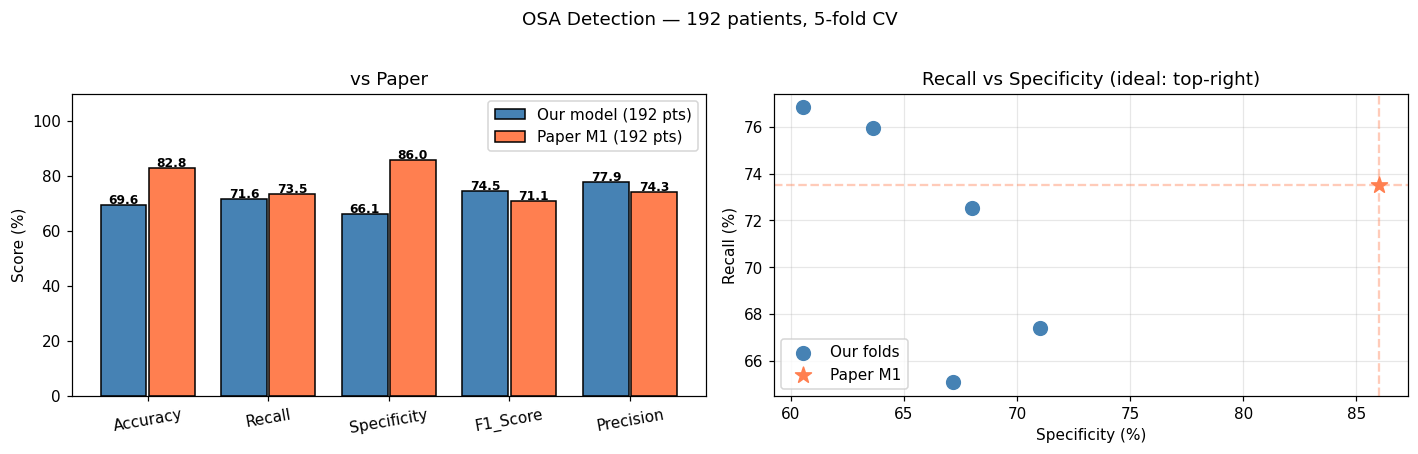


Model params: 178,946
Thresholds used: [0.4800000000000001, 0.43000000000000005, 0.39000000000000007, 0.4700000000000001, 0.45000000000000007]
(Should be ~0.40–0.55, not 0.15–0.29)


In [24]:
# ══════════════════════════════════════════════════════
# RESULTS SUMMARY
# ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams['figure.dpi'] = 110

paper = dict(Accuracy=82.81, Recall=73.51, Specificity=86.01, F1_Score=71.06, Precision=74.35)
df    = pd.DataFrame(all_results).set_index('Fold')
means = df.drop(columns='Threshold').mean()
stds  = df.drop(columns='Threshold').std()

print('Per-fold results:')
print(df.round(4).to_string())
print()
print(f'{"Metric":<16}  {"Mean±Std":>15}  {"Paper":>8}  {"Gap":>7}')
print('─' * 55)
for k in ['Accuracy','BalancedAcc','Recall','Specificity','F1_Score']:
    v = means[k]*100; s = stds[k]*100; p = paper.get(k,0)
    diff_str = f'{v-p:+.2f}%' if p else 'n/a'
    print(f'{k:<16}  {v:>6.2f}%±{s:>4.2f}%  {p if p else "":>7}  {diff_str:>7}')

df.to_csv(RESULTS_DIR / 'cv_results.csv')

# Comparison chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: bar chart vs paper
metrics  = ['Accuracy','Recall','Specificity','F1_Score','Precision']
our_vals = [means[k]*100 for k in metrics]
pap_vals = [paper[k] for k in metrics]
x = np.arange(len(metrics))
axes[0].bar(x-0.2, our_vals, 0.38, label=f'Our model ({len(pids)} pts)', color='steelblue', edgecolor='k')
axes[0].bar(x+0.2, pap_vals, 0.38, label='Paper M1 (192 pts)', color='coral', edgecolor='k')
for i,(o,p) in enumerate(zip(our_vals,pap_vals)):
    axes[0].text(i-0.2, o+0.5, f'{o:.1f}', ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i+0.2, p+0.5, f'{p:.1f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics, rotation=10)
axes[0].set_ylim(0, 110); axes[0].set_ylabel('Score (%)')
axes[0].set_title('vs Paper'); axes[0].legend()

# Right: Recall vs Specificity per fold
recs  = [r['Recall']*100  for r in all_results]
specs = [r['Specificity']*100 for r in all_results]
axes[1].scatter(specs, recs, c='steelblue', s=80, zorder=3, label='Our folds')
axes[1].scatter([86.01], [73.51], c='coral', s=120, marker='*', zorder=4, label='Paper M1')
axes[1].set_xlabel('Specificity (%)'); axes[1].set_ylabel('Recall (%)')
axes[1].set_title('Recall vs Specificity (ideal: top-right)')
axes[1].axhline(73.51, color='coral', ls='--', alpha=0.4)
axes[1].axvline(86.01, color='coral', ls='--', alpha=0.4)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'OSA Detection — {len(pids)} patients, {N_FOLDS}-fold CV', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nModel params: {sum(p.numel() for p in SleepApneaBiLSTM().parameters()):,}')
print(f'Thresholds used: {[r["Threshold"] for r in all_results]}')
print('(Should be ~0.40–0.55, not 0.15–0.29)')



Best Fold: 2
Threshold      0.430000
Accuracy       0.710550
BalancedAcc    0.686760
Precision      0.780300
Recall         0.768236
Specificity    0.605283
F1_Score       0.774221
Name: 2, dtype: float64


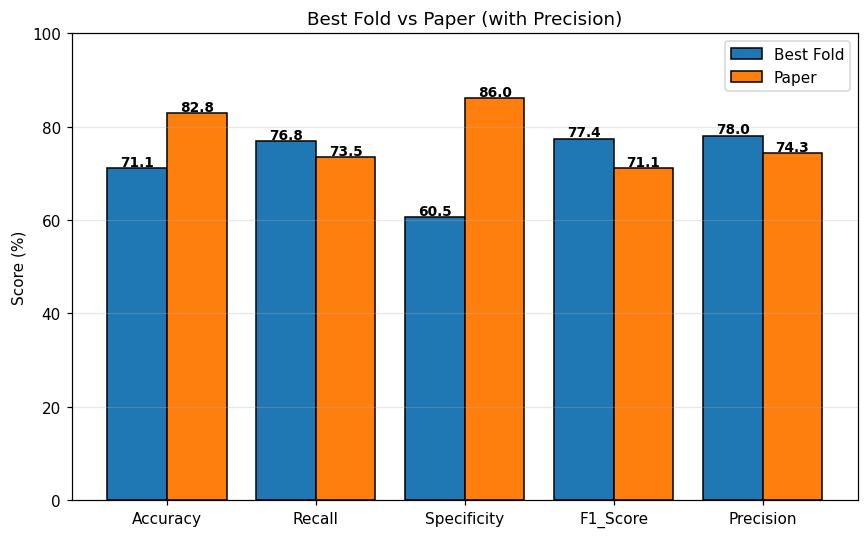

In [ ]:
# ================================
# BEST FOLD vs PAPER (+ Precision)
# ================================

best_idx = df['F1_Score'].idxmax()
best_row = df.loc[best_idx]

print(f"\nBest Fold: {best_idx}")
print(best_row)

# Add Precision
metrics = ['Accuracy', 'Recall', 'Specificity', 'F1_Score', 'Precision']

best_vals = [best_row[k]*100 for k in metrics]

# Paper values (handle missing Precision)
paper_vals = []
for k in metrics:
    if k in paper:
        paper_vals.append(paper[k])
    else:
        paper_vals.append(0)  # placeholder

# Plot
plt.figure(figsize=(8,5))
x = np.arange(len(metrics))

plt.bar(x - 0.2, best_vals, width=0.4, label='Best Fold', edgecolor='k')
plt.bar(x + 0.2, paper_vals, width=0.4, label='Paper', edgecolor='k')

# Labels
for i, (b, p) in enumerate(zip(best_vals, paper_vals)):
    plt.text(i-0.2, b+0.5, f'{b:.1f}', ha='center', fontsize=9, fontweight='bold')
    
    if metrics[i] in paper:
        plt.text(i+0.2, p+0.5, f'{p:.1f}', ha='center', fontsize=9, fontweight='bold')
    else:
        plt.text(i+0.2, p+0.5, "N/A", ha='center', fontsize=9)

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("Best Fold vs Paper (with Precision)")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()